In [1]:
!pip install kagglehub timm grad-cam

  Using cached grad-cam-1.5.5.tar.gz (7.8 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=2f1e4c52ad74567ecac97a694305ad5ea229b7fa8cf676de2f028001045ce193
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import timm
from sklearn.metrics import accuracy_score, classification_report
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
import kagglehub

#Download latest version of the dataset
path = kagglehub.dataset_download("fari4117/cdffake-v2-dataset")
print("Raw kagglehub path:", path)

#Actual images are inside CDFFAKE V2 Dataset
data_dir = os.path.join(path, "CDFFAKE V2 Dataset")
print("Image root:", data_dir)

100%|██████████| 130M/130M [00:00<00:00, 170MB/s]

Extracting files...


Raw kagglehub path: /root/.cache/kagglehub/datasets/fari4117/cdffake-v2-dataset/versions/1
Image root: /root/.cache/kagglehub/datasets/fari4117/cdffake-v2-dataset/versions/1/CDFFAKE V2 Dataset


In [ ]:
#Data preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

#ImageFolder expects class subfolders (Deepfake, Real, Tempered)
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
print("Classes:", dataset.classes) 

num_classes = len(dataset.classes)

#Train/test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

print("Train samples:", len(train_ds))
print("Test samples:", len(test_ds))

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Classes: ['Deepfake', 'Real', 'Tempered']
Train samples: 4920
Test samples: 1230
Device: cuda


In [ ]:
cnn_model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=num_classes
)

cnn_model = cnn_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [6]:
EPOCHS_CNN = 5

for epoch in range(EPOCHS_CNN):
    cnn_model.train()
    total_loss = 0.0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer_cnn.zero_grad()
        outputs = cnn_model(images)              # [B, 3]
        loss = criterion(outputs, labels)        # labels in {0,1,2}
        loss.backward()
        optimizer_cnn.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"[CNN] Epoch {epoch+1}/{EPOCHS_CNN} | Loss: {avg_loss:.4f}")

torch.save(cnn_model.state_dict(), "cnn_forgery_model.pth")
print("CNN model saved to cnn_forgery_model.pth")

100%|██████████| 154/154 [00:37<00:00,  4.10it/s]


[CNN] Epoch 1/5 | Loss: 0.4827


100%|██████████| 154/154 [00:36<00:00,  4.23it/s]


[CNN] Epoch 2/5 | Loss: 0.1015


100%|██████████| 154/154 [00:34<00:00,  4.41it/s]


[CNN] Epoch 3/5 | Loss: 0.0566


100%|██████████| 154/154 [00:35<00:00,  4.36it/s]


[CNN] Epoch 4/5 | Loss: 0.0262


100%|██████████| 154/154 [00:35<00:00,  4.35it/s]


[CNN] Epoch 5/5 | Loss: 0.0146
CNN model saved to cnn_forgery_model.pth


In [7]:
cnn_model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print("CNN Test Accuracy:", acc)
print("\nCNN Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=dataset.classes))

CNN Test Accuracy: 0.9422764227642276

CNN Classification Report:

              precision    recall  f1-score   support

    Deepfake       0.91      0.93      0.92       434
        Real       0.92      0.90      0.91       404
    Tempered       1.00      1.00      1.00       392

    accuracy                           0.94      1230
   macro avg       0.94      0.94      0.94      1230
weighted avg       0.94      0.94      0.94      1230



In [ ]:
vit_model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=num_classes
)

vit_model = vit_model.to(device)
optimizer_vit = optim.Adam(vit_model.parameters(), lr=2e-5)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [9]:
EPOCHS_VIT = 3

for epoch in range(EPOCHS_VIT):
    vit_model.train()
    total_loss = 0.0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer_vit.zero_grad()
        outputs = vit_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_vit.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"[ViT] Epoch {epoch+1}/{EPOCHS_VIT} | Loss: {avg_loss:.4f}")

torch.save(vit_model.state_dict(), "vit_forgery_model.pth")
print("ViT model saved to vit_forgery_model.pth")

100%|██████████| 154/154 [02:47<00:00,  1.08s/it]


[ViT] Epoch 1/3 | Loss: 0.1502


100%|██████████| 154/154 [02:45<00:00,  1.08s/it]


[ViT] Epoch 2/3 | Loss: 0.0419


100%|██████████| 154/154 [02:46<00:00,  1.08s/it]


[ViT] Epoch 3/3 | Loss: 0.0283
ViT model saved to vit_forgery_model.pth


In [10]:
vit_model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vit_model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print("ViT Test Accuracy:", acc)
print("\nViT Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=dataset.classes))

ViT Test Accuracy: 0.9634146341463414

ViT Classification Report:

              precision    recall  f1-score   support

    Deepfake       0.96      0.93      0.95       434
        Real       0.93      0.96      0.95       404
    Tempered       1.00      1.00      1.00       392

    accuracy                           0.96      1230
   macro avg       0.96      0.96      0.96      1230
weighted avg       0.96      0.96      0.96      1230



In [ ]:
#Pick the last EfficientNet block as target layer
target_layers = [cnn_model.blocks[-1]]

cam = GradCAM(
    model=cnn_model,
    target_layers=target_layers
)

#Take one example from test set
img_tensor, label_idx = test_ds[0]
input_tensor = img_tensor.unsqueeze(0).to(device)

cnn_model.eval()
grayscale_cam = cam(input_tensor=input_tensor)[0]

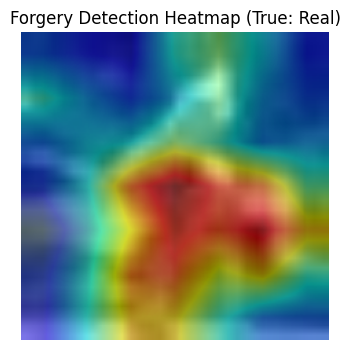

In [ ]:
#Prepare original image for overlay
rgb_img = np.transpose(img_tensor.numpy(), (1, 2, 0))
rgb_img = (rgb_img * 0.5 + 0.5).clip(0, 1) 

cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(4,4))
plt.imshow(cam_image)
plt.title(f"Forgery Detection Heatmap (True: {dataset.classes[label_idx]})")
plt.axis("off")
plt.show()

In [ ]:
class_names = dataset.classes

def predict_image(path, model, device=device):
    model.eval()
    img = Image.open(path).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_t)
        pred_idx = outputs.argmax(dim=1).item()

    return class_names[pred_idx]

#Example in use
print(predict_image("/content/post10272025.png", cnn_model))

Tempered
